# Exploratory Data Analysis Project - Social Anxiety

In this project, I clean and analyse the 'Social Anxiety Dataset' dataset from Kaggle. This dataset contains information like demographics, lifestyle, health indicators, mental health history, and life events, about individuals with varying levels of social anxiety.

Additional information about some of the features in the dataset:
* Sleep - in hours / day
* Physical Activity - in hours / week
* Caffeine Intake - in milligrams / day
* Alcohol Consumption - in drinks / week
* Heart Rate - in beats / minute (bpm)
* Breathing Rate - in breaths / minute
* Therapy Sessions - in sessions / month

In [104]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# setting display options
pd.options.display.expand_frame_repr = False
pd.options.display.max_columns = 30
pd.options.display.max_rows = 100

### Loading Dataset

In [105]:
raw_df = pd.read_csv(r'Data_SocialAnxiety.csv')
raw_df.info()
raw_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


### Data Cleaning

Renaming Columns

In [106]:
for column_name in raw_df:
    new_column_name = column_name.replace(' ','_')
    raw_df.rename(columns={column_name:new_column_name.capitalize()}, inplace=True)

raw_df.rename(columns={'Sleep_hours': 'Sleep',
                       'Physical_activity_(hrs/week)': 'Physical_activity',
                       'Caffeine_intake_(mg/day)': 'Caffeine_intake',
                       'Alcohol_consumption_(drinks/week)': 'Alcohol_consumption',
                       'Family_history_of_anxiety': 'Family_history',
                       'Stress_level_(1-10)': 'Stress_level',
                       'Heart_rate_(bpm)': 'Heart_rate',
                       'Breathing_rate_(breaths/min)': 'Breathing_rate',
                       'Sweating_level_(1-5)': 'Sweating_level',
                       'Therapy_sessions_(per_month)': 'Therapy_sessions',
                       'Recent_major_life_event': 'Major_life_events',
                       'Diet_quality_(1-10)': 'Diet_quality',
                       'Anxiety_level_(1-10)': 'Anxiety_level'}, inplace=True)

Correcting Datatypes

In [107]:
raw_df['Anxiety_level'] = raw_df['Anxiety_level'].astype('int')

Correcting Column Values

In [108]:
# Converting Strings to UPPER CASE
columns = ['Gender', 'Occupation', 'Smoking', 'Family_history', 'Dizziness', 
           'Medication', 'Major_life_events']
for column in columns:
    raw_df[column] = raw_df[column].str.upper()

In [109]:
# Rounding Floating points
raw_df['Sleep'] = raw_df['Sleep'].round(1)
raw_df['Physical_activity'] = raw_df['Physical_activity'].round(1)

In [110]:
# Adding a new column Age_group
age_groups = pd.cut(x=raw_df['Age'], bins=[18, 25, 40, 55, 65], include_lowest=True, 
                    labels=['YOUNG ADULT', 'ADULT', 'MIDDLE AGED', 'SENIOR'])
raw_df.insert(loc=1, column='Age_group', value=age_groups)

Fixing Null Values

In [111]:
# Checking for Null values
print(raw_df.isna().sum())

Age                    0
Age_group              0
Gender                 0
Occupation             0
Sleep                  0
Physical_activity      0
Caffeine_intake        0
Alcohol_consumption    0
Smoking                0
Family_history         0
Stress_level           0
Heart_rate             0
Breathing_rate         0
Sweating_level         0
Dizziness              0
Medication             0
Therapy_sessions       0
Major_life_events      0
Diet_quality           0
Anxiety_level          0
dtype: int64


Fixing Duplicates

In [112]:
# Checking for duplicates
print(raw_df.duplicated().sum())

0


### Statistical Analysis

Describe

In [113]:
raw_df.describe()

,Age,Sleep,Physical_activity,Caffeine_intake,Alcohol_consumption,Stress_level,Heart_rate,Breathing_rate,Sweating_level,Therapy_sessions,Diet_quality,Anxiety_level
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.241727,6.650691,2.942136,286.090000,9.701636,5.856364,90.916000,20.957545,3.080636,2.427818,5.181818,3.929364
std,13.236140,1.227509,1.827825,144.813157,5.689713,2.927202,17.325721,5.160107,1.398877,2.183106,2.895243,2.122533
min,18.000000,2.300000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000
25%,29.000000,5.900000,1.500000,172.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000
50%,40.000000,6.700000,2.800000,273.000000,10.000000,6.000000,92.000000,21.000000,3.000000,2.000000,5.000000,4.000000
75%,51.000000,7.500000,4.200000,382.000000,15.000000,8.000000,106.000000,25.000000,4.000000,4.000000,8.000000,5.000000
max,64.000000,11.300000,10.100000,599.000000,19.000000,10.000000,119.000000,29.000000,5.000000,12.000000,10.000000,10.000000


Correlation

                          Age     Sleep  Physical_activity  Caffeine_intake  Alcohol_consumption  Stress_level  Heart_rate  Breathing_rate  Sweating_level  Therapy_sessions  Diet_quality  Anxiety_level
Age                  1.000000 -0.148349           0.037240        -0.038398            -0.015953     -0.044824   -0.032022       -0.013896       -0.020483         -0.087185      0.048677      -0.074316
Sleep               -0.148349  1.000000           0.174526        -0.208659            -0.068068     -0.177315   -0.138254       -0.119872       -0.118197         -0.309251      0.154110      -0.493836
Physical_activity    0.037240  0.174526           1.000000        -0.115298            -0.032936     -0.103475   -0.076846       -0.071195       -0.075107         -0.188324      0.085587      -0.243187
Caffeine_intake     -0.038398 -0.208659          -0.115298         1.000000             0.036401      0.121424    0.076555        0.080000        0.076011          0.216682     -0.089457      

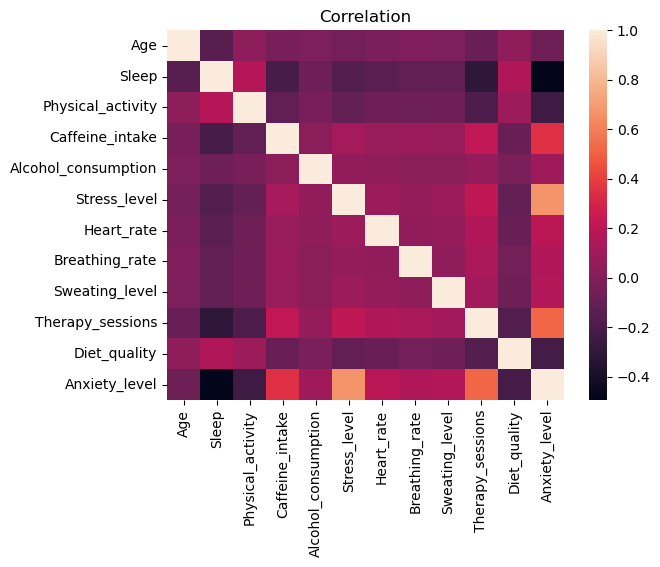

In [114]:
print(raw_df.corr(numeric_only=True))
sns.heatmap(raw_df.corr(numeric_only=True))
plt.title('Correlation')
plt.show()

Covariance

In [115]:
raw_df.cov(numeric_only=True)

,Age,Sleep,Physical_activity,Caffeine_intake,Alcohol_consumption,Stress_level,Heart_rate,Breathing_rate,Sweating_level,Therapy_sessions,Diet_quality,Anxiety_level
Age,175.195404,-2.410300,0.900960,-73.599264,-1.201441,-1.736710,-7.343544,-0.949097,-0.379254,-2.519281,1.865401,-2.087842
Sleep,-2.410300,1.506778,0.391580,-37.091025,-0.475401,-0.637122,-2.940318,-0.759281,-0.202961,-0.828725,0.547697,-1.286655
Physical_activity,0.900960,0.391580,3.340946,-30.518485,-0.342532,-0.553634,-2.433600,-0.671499,-0.192042,-0.751477,0.452925,-0.943473
Caffeine_intake,-73.599264,-37.091025,-30.518485,20970.850341,29.992216,51.471243,192.074658,59.780074,15.397961,68.502451,-37.506773,107.779792
Alcohol_consumption,-1.201441,-0.475401,-0.342532,29.992216,32.372831,0.857858,4.364152,0.695578,0.188167,0.769261,-0.487615,1.215217
Stress_level,-1.736710,-0.637122,-0.553634,51.471243,0.857858,8.568511,4.486706,0.945261,0.347796,1.336208,-0.932969,4.149959
Heart_rate,-7.343544,-2.940318,-2.433600,192.074658,4.364152,4.486706,300.180597,4.763594,1.506729,5.854924,-4.324666,6.946698
Breathing_rate,-0.949097,-0.759281,-0.671499,59.780074,0.695578,0.945261,4.763594,26.626709,0.349001,1.565760,-0.807263,1.720067
Sweating_level,-0.379254,-0.202961,-0.192042,15.397961,0.188167,0.347796,1.506729,0.349001,1.956857,0.359353,-0.313690,0.475285
Therapy_sessions,-2.519281,-0.828725,-0.751477,68.502451,0.769261,1.336208,5.854924,1.565760,0.359353,4.765950,-1.092884,2.398438


### Cleaned Data

In [116]:
raw_df.info()
raw_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  11000 non-null  int64   
 1   Age_group            11000 non-null  category
 2   Gender               11000 non-null  object  
 3   Occupation           11000 non-null  object  
 4   Sleep                11000 non-null  float64 
 5   Physical_activity    11000 non-null  float64 
 6   Caffeine_intake      11000 non-null  int64   
 7   Alcohol_consumption  11000 non-null  int64   
 8   Smoking              11000 non-null  object  
 9   Family_history       11000 non-null  object  
 10  Stress_level         11000 non-null  int64   
 11  Heart_rate           11000 non-null  int64   
 12  Breathing_rate       11000 non-null  int64   
 13  Sweating_level       11000 non-null  int64   
 14  Dizziness            11000 non-null  object  
 15  Medication         

,Age,Age_group,Gender,Occupation,Sleep,Physical_activity,Caffeine_intake,Alcohol_consumption,Smoking,Family_history,Stress_level,Heart_rate,Breathing_rate,Sweating_level,Dizziness,Medication,Therapy_sessions,Major_life_events,Diet_quality,Anxiety_level
0,29,ADULT,FEMALE,ARTIST,6.0,2.7,181,10,YES,NO,10,114,14,4,NO,YES,3,YES,7,5
1,46,MIDDLE AGED,OTHER,NURSE,6.2,5.7,200,8,YES,YES,1,62,23,2,YES,NO,2,NO,8,3
2,64,SENIOR,MALE,OTHER,5.0,3.7,117,4,NO,YES,1,91,28,3,NO,NO,1,YES,1,1
3,20,YOUNG ADULT,FEMALE,SCIENTIST,5.8,2.8,360,6,YES,NO,4,86,17,3,NO,NO,0,NO,1,2
4,49,MIDDLE AGED,FEMALE,OTHER,8.2,2.3,247,4,YES,NO,1,98,19,4,YES,YES,1,NO,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,YOUNG ADULT,FEMALE,ENGINEER,6.1,3.1,566,9,YES,NO,8,91,28,1,YES,YES,1,NO,3,6
10996,50,MIDDLE AGED,OTHER,TEACHER,6.6,3.6,64,17,YES,NO,7,95,17,3,NO,NO,2,NO,7,3
10997,29,ADULT,MALE,NURSE,6.7,6.9,159,14,NO,NO,8,72,16,1,YES,YES,2,YES,7,4
10998,53,MIDDLE AGED,OTHER,ARTIST,5.7,2.7,248,8,NO,NO,4,112,28,3,YES,YES,1,YES,2,4


### Data Analysis

##### Q1. How does Physical Activity affect Sleep across different Age Groups?

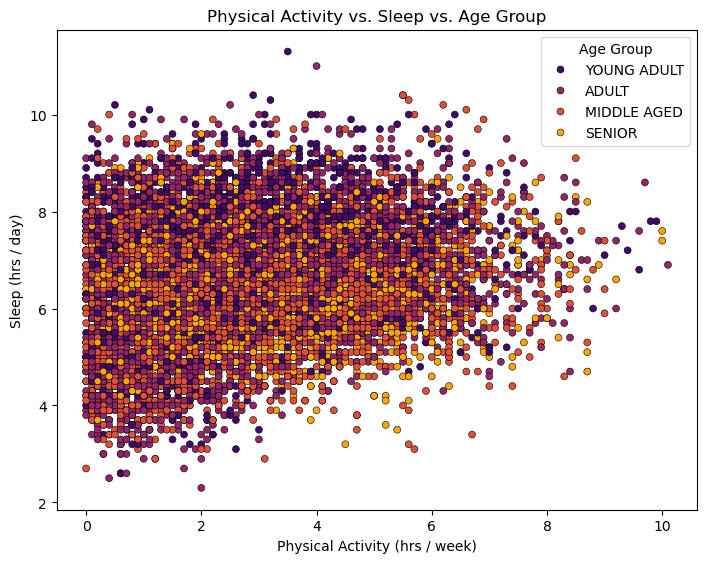

In [117]:
df = raw_df[['Physical_activity', 'Sleep', 'Age', 'Age_group']]

ax = plt.axes((0,0,1,1))
ax = sns.scatterplot(data=df, x='Physical_activity', y='Sleep', hue='Age_group', 
                     palette='inferno', s=25, edgecolor='k', linewidth=0.4, ax=ax)
ax.set_xlabel('Physical Activity (hrs / week)')
ax.set_ylabel('Sleep (hrs / day)')
ax.set_title('Physical Activity vs. Sleep vs. Age Group')
ax.legend(loc='best', title='Age Group')
plt.show()

Key points to observe from the plot:
1. There is more variance in Sleep for people who have low Physical Activity. This shows people who are conscious about exercise, are also conscious about getting about 6-8 hrs of Sleep per day.
2. There isn't much correlation between Physical Activity and Age.
3. People in different Age groups show different Sleep patterns in general:
    1. Most young adults get around 7-9 hrs of Sleep per day.
    2. Adults are split towards the extremes.
    3. As the Age increases, most middle aged and seniors settle to get around 6-7 hrs of Sleep per day.

##### Q2. What Occupation has the highest Stress Levels?

Stress_level     10     9      8      7      6      5     4      3     2      1 
Occupation                                                                      
DOCTOR        12.95  12.83  13.42   9.62   6.89   9.14  8.31   9.86  8.67   8.31
ATHLETE       12.17  13.02  12.17   8.88  10.10   9.37  7.91   9.37  9.00   8.03
NURSE         11.38  14.29  11.38   8.71  10.92   9.64  7.78   8.01  9.29   8.59
LAWYER        12.36  13.97  10.75   8.65   9.89   9.15  9.89   7.54  8.90   8.90
STUDENT       13.10  12.07  13.33   8.54   7.74   8.54  9.91   9.00  9.68   8.09
MUSICIAN      12.56  10.87  13.57   9.87   8.52  10.43  8.30   8.18  8.97   8.74
TEACHER       13.14  13.14  10.90   8.18   9.05   9.67  8.43   9.17  9.67   8.67
OTHER         10.60  12.98  13.10   9.40   9.52   9.40  8.21   8.69  9.64   8.45
FREELANCER    13.72  12.41  10.38   8.11  10.26   8.83  9.07   8.11  9.31   9.79
ENGINEER      12.97  12.24  10.92  10.92   7.32   9.00  9.84   7.92  8.76  10.08
ARTIST        13.18   9.91  

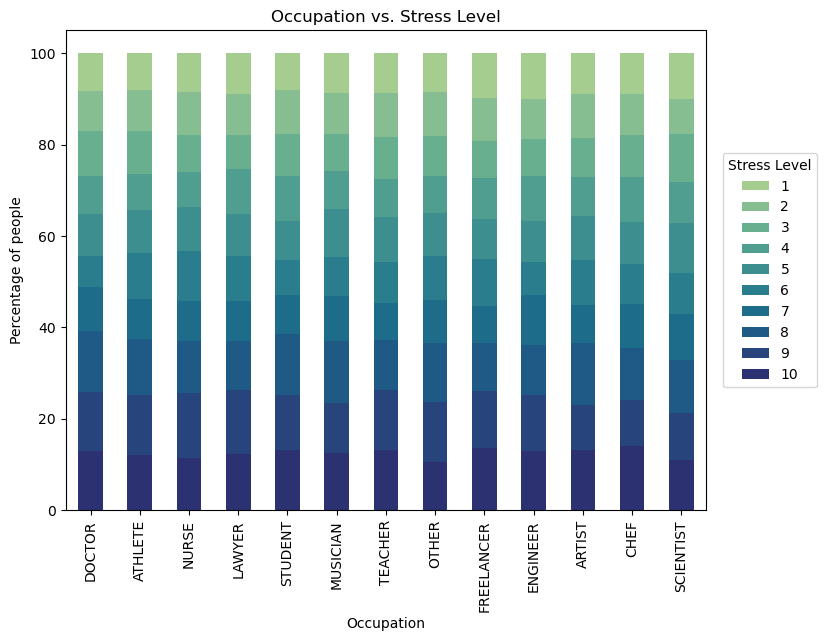

In [118]:
df = raw_df[['Occupation', 'Stress_level', 'Age']]
df_mean = df.groupby('Occupation')['Stress_level'].mean().sort_values(ascending=False)
df = df.groupby(['Occupation', 'Stress_level']).count().unstack()['Age']
df = (df.div(df.sum(axis=1), axis=0) * 100).round(2)  # converting to percentages
df = df.sort_index(axis='columns', ascending=False)
df = df.loc[df_mean.index]  # sorting occupations according to mean stress levels
print(df)

ax = plt.axes((0,0,1,1))
ax = df.plot(kind='bar', stacked=True, title='Occupation vs. Stress Level', ax=ax, colormap='crest_r')
ax.set_ylabel('Percentage of people')
ax.legend(reverse=True, loc='center', bbox_to_anchor=(1.1, 0.5), title='Stress Level')
plt.show()

Key points to observe from the plot:
1. The cumulative percentage of people in higher Stress Levels (8-10) decrease from left to right. This shows there are more people with higher Stress Levels in the jobs on the left than in the jobs on the right.
2. Doctors, Athletes, and Nurses have higher stress.
3. Scientists, Chefs, and Artists have lower Stress.

##### Q3. Do Major Life Events affect Stress Levels and Heart Rates?

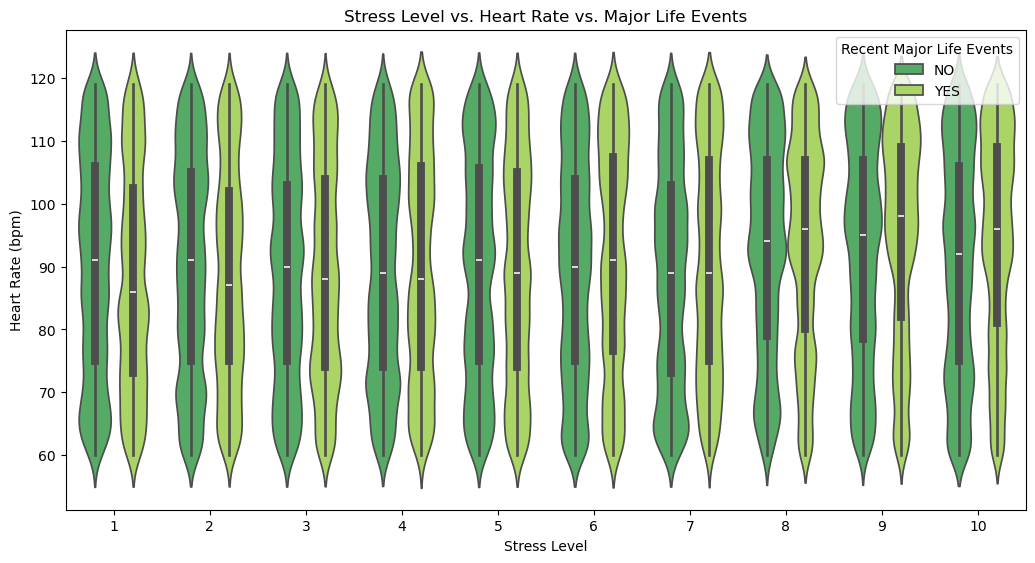

In [119]:
df = raw_df[['Heart_rate', 'Stress_level', 'Major_life_events']]

ax = plt.axes((0,0,1.5,1))
ax = sns.violinplot(data=df, x='Stress_level', y='Heart_rate', hue='Major_life_events', 
                    palette='summer', saturation=1, bw_adjust=0.5, ax=ax)
ax.set_xlabel('Stress Level')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_title('Stress Level vs. Heart Rate vs. Major Life Events')
ax.legend(title='Recent Major Life Events')
plt.show()

Key points to observe from the plot:
1. People with higher Stress Levels have higher Heart Rates.
2. In low Stress Levels, people who have experienced any recent Major Life Events have lower Heart rates than people who haven't. Whereas in high Stress Levels, people who have experienced recent Major Life Events have a higher Heart Rate than people who haven't. This could be because Major Life Events can either numb a person and reduce their Stress Levels and Heart Rates, or amplify their Stress Levels and Heart Rates.
3. In lower Stress Levels, the number of people who haven't had any Recent Major Life Events are more than the number of people who have had.

##### Q4. Can Major Life Events affect Smoking and Alcohol Consumption?

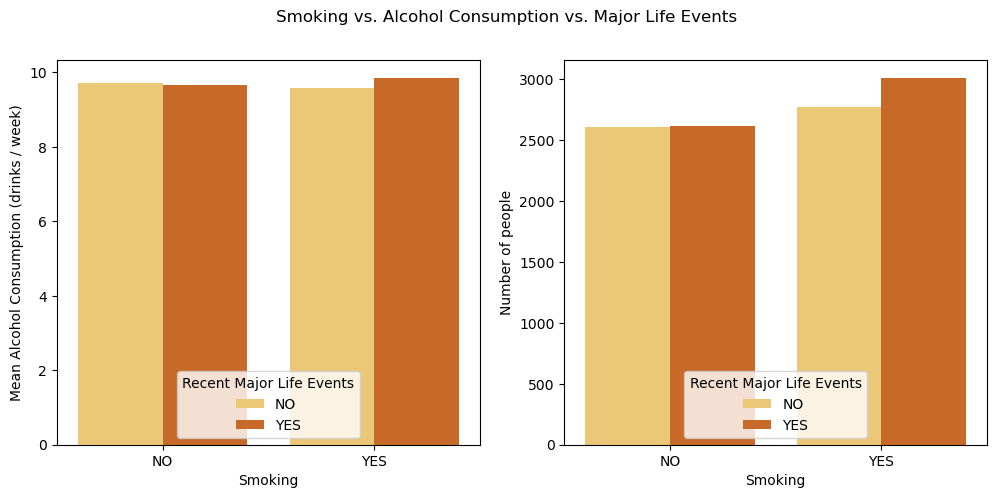

In [120]:
df = raw_df[['Smoking', 'Alcohol_consumption', 'Major_life_events']]
df = df.groupby(['Major_life_events', 'Smoking']).aggregate(Count=('Alcohol_consumption', 'count'),
                                                            Mean=('Alcohol_consumption', 'mean'))

fig = plt.figure(num=1, figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1 = sns.barplot(data=df, x='Smoking', y='Mean', hue='Major_life_events',
                  palette='YlOrBr', ax=ax1)
ax1.set_xlabel('Smoking')
ax1.set_ylabel('Mean Alcohol Consumption (drinks / week)')
ax1.legend(loc='lower center', title='Recent Major Life Events')

ax2 = fig.add_subplot(1, 2, 2)
ax2 = sns.barplot(data=df, x='Smoking', y='Count', hue='Major_life_events',
                  palette='YlOrBr', ax=ax2)
ax2.set_xlabel('Smoking')
ax2.set_ylabel('Number of people')
ax2.legend(loc='lower center', title='Recent Major Life Events')

plt.suptitle('Smoking vs. Alcohol Consumption vs. Major Life Events')
plt.show()

Key points to observe from the plot:
1. Major Life Events increase Smoking for people who already used to smoke, but has no effect on people who didn't used to smoke.
1. Major Life Events don't have much effect on Alcohol Consumption.

##### Q5. How does Caffeine Intake affect Sleep across different Age Groups?

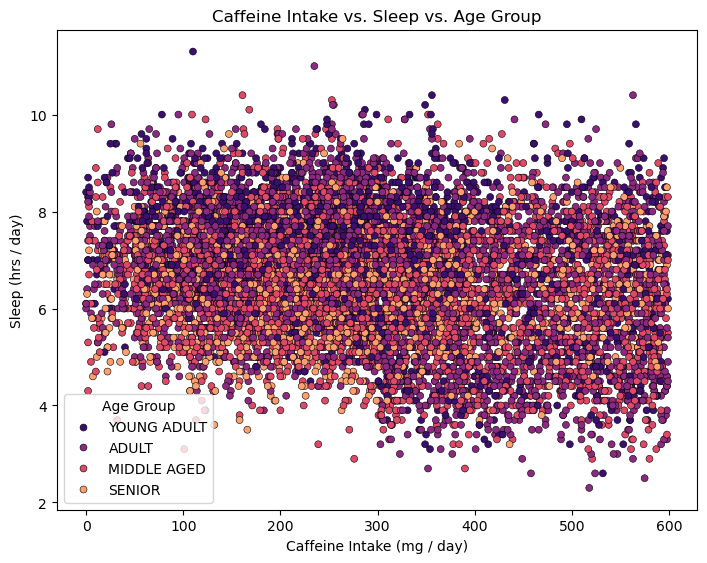

In [121]:
df = raw_df[['Caffeine_intake', 'Sleep', 'Age', 'Age_group']]

ax = plt.axes((0,0,1,1))
ax = sns.scatterplot(data=df, x='Caffeine_intake', y='Sleep', hue='Age_group', 
                     palette='magma', s=25, edgecolor='k', linewidth=0.4, ax=ax)
ax.set_xlabel('Caffeine Intake (mg / day)')
ax.set_ylabel('Sleep (hrs / day)')
ax.set_title('Caffeine Intake vs. Sleep vs. Age Group')
ax.legend(loc='best', title='Age Group')
plt.show()

Key points to observe from the plot:
1. There isn't any correlation between Caffeine Intake and Age group.
2. There is a lot more variation in Sleep hours among people who have high Caffeine Intake than people who have low Caffeine intake.
3. People who Sleep less than 4 hrs per day, have a high Caffeine Intake.

##### Q6. What effect does Smoking have on Breath Rate?

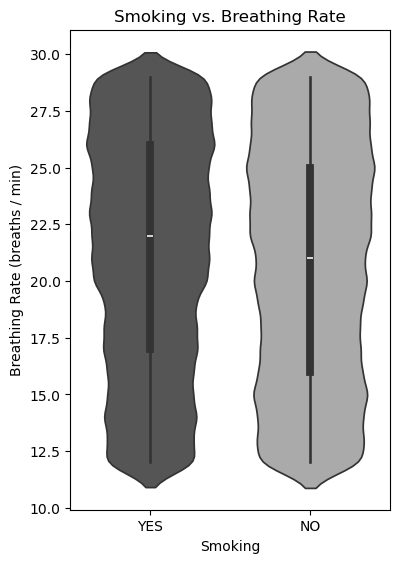

In [122]:
df = raw_df[['Breathing_rate', 'Smoking']]

ax = plt.axes((0,0,0.5,1))
ax = sns.violinplot(data=df, x='Smoking', y='Breathing_rate', hue='Smoking', 
                    palette='binary_r', saturation=1, bw_adjust=0.6, ax=ax)
ax.set_xlabel('Smoking')
ax.set_ylabel('Breathing Rate (breaths / min)')
ax.set_title('Smoking vs. Breathing Rate')
plt.show()

Key points to observe from the plot:
1. Non-Smokers have lower Breath Rate on average than people who Smoke.

##### Q7. How does Sleep and Physical Activity affect Stress?

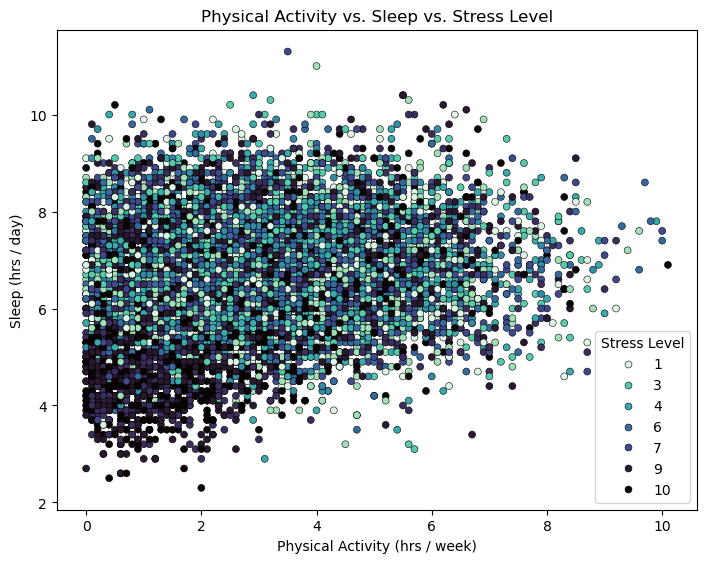

In [123]:
df = raw_df[['Physical_activity', 'Sleep', 'Stress_level']]

ax = plt.axes((0,0,1,1))
ax = sns.scatterplot(data=df, x='Physical_activity', y='Sleep', hue='Stress_level', 
                     palette='mako_r', s=25, edgecolor='k', linewidth=0.4, ax=ax)
ax.set_xlabel('Physical Activity (hrs / week)')
ax.set_ylabel('Sleep (hrs / day)')
ax.set_title('Physical Activity vs. Sleep vs. Stress Level')
ax.legend(loc='best', title='Stress Level')
plt.show()

Key points to observe from the plot:
1. People with low Sleep and low Physical Activity are also the people with high Stress. Now, which one is the cause and which one is the effect, is debateable.

##### Q8. Do people with high Anxiety Levels consume more Alcohol and Smoke more?

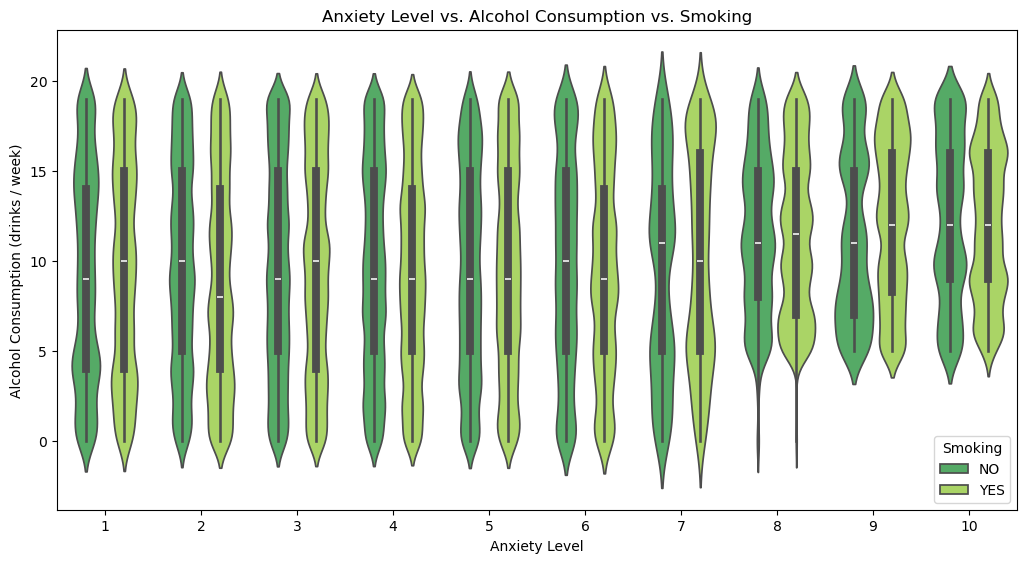

In [124]:
df = raw_df[['Anxiety_level', 'Smoking', 'Alcohol_consumption']]

ax = plt.axes((0,0,1.5,1))
ax = sns.violinplot(data=df, x='Anxiety_level', y='Alcohol_consumption', hue='Smoking', 
                    palette='summer', saturation=1, bw_adjust=0.5, ax=ax)
ax.set_xlabel('Anxiety Level')
ax.set_ylabel('Alcohol Consumption (drinks / week)')
ax.set_title('Anxiety Level vs. Alcohol Consumption vs. Smoking')
ax.legend(title='Smoking')
plt.show()

Key points to observe from the plot:
1. People who have high Anxiety Levels also consume more alcohol on average.
2. Among the people with high Anxiety Levels, there are more smokers than non-smokers.

##### Q9. How does Anxiety Level affect Caffeine Intake and Therapy Sessions?

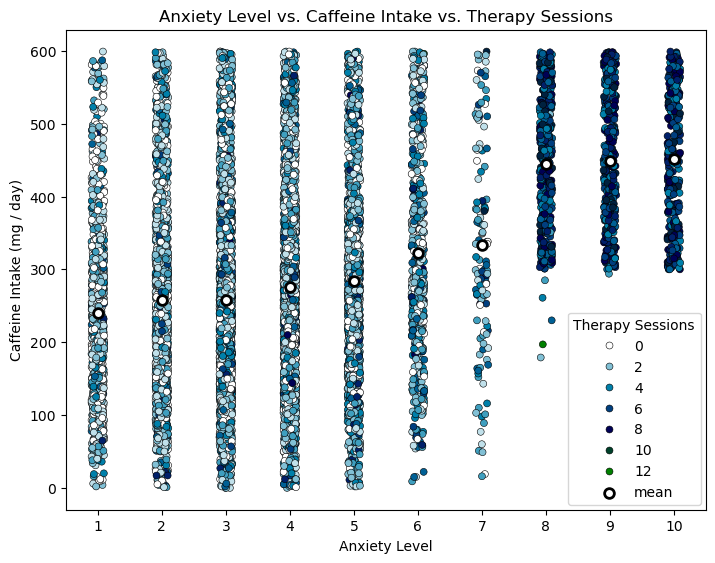

In [125]:
df = raw_df[['Anxiety_level', 'Caffeine_intake', 'Therapy_sessions']]
df_mean = df.groupby('Anxiety_level')['Caffeine_intake'].mean().reset_index()

ax = plt.axes((0,0,1,1))
ax = sns.stripplot(data=df, x='Anxiety_level', y='Caffeine_intake', hue='Therapy_sessions', 
                   palette='ocean_r', s=5, edgecolor='k', linewidth=0.4, ax=ax)
ax = sns.stripplot(data=df_mean, x='Anxiety_level', y='Caffeine_intake', 
                   color='w', s=7, edgecolor='k', linewidth=2, ax=ax, label='mean')
ax.set_xlabel('Anxiety Level')
ax.set_ylabel('Caffeine Intake (mg / day)')
ax.set_title('Anxiety Level vs. Caffeine Intake vs. Therapy Sessions')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:8], labels=labels[0:8], loc='center', bbox_to_anchor=(0.888, 0.21), title='Therapy Sessions')
plt.show()

Key points to observe from the plot:
1. Caffeine Intake increases with Anxiety Level. People with high Anxiety Levels consume considerably high amount of caffeine.
2. People with high Anxiety Levels also take more Therapy Sessions.
3. People who take more Therapy Sessions consume more Caffeine.

##### Q10. How does Sleep and Physical Activity affect Anxiety?

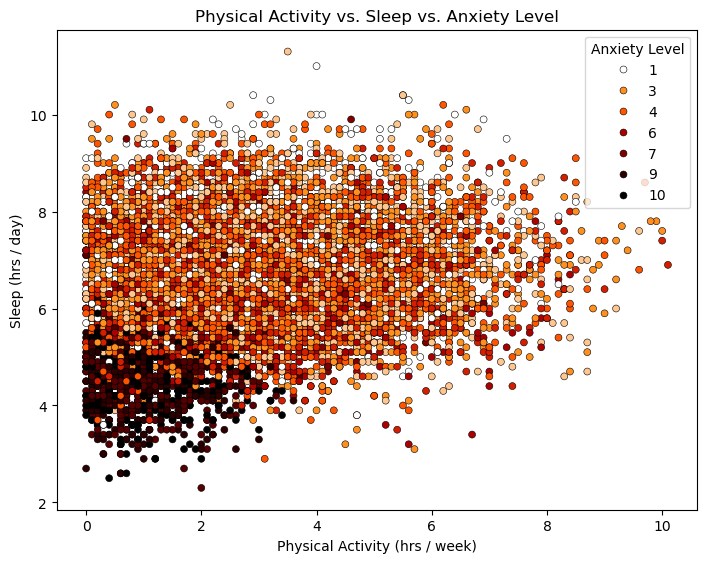

In [126]:
df = raw_df[['Physical_activity', 'Sleep', 'Anxiety_level']]

ax = plt.axes((0,0,1,1))
ax = sns.scatterplot(data=df, x='Physical_activity', y='Sleep', hue='Anxiety_level', 
                     palette='gist_heat_r', s=25, edgecolor='k', linewidth=0.4, ax=ax)
ax.set_xlabel('Physical Activity (hrs / week)')
ax.set_ylabel('Sleep (hrs / day)')
ax.set_title('Physical Activity vs. Sleep vs. Anxiety Level')
ax.legend(loc='best', title='Anxiety Level')
plt.show()

Key points to observe from the plot:
1. People with low Sleep and low Physical Activity are also the people with high Anxiety. This plot looks very similar to the plot between Physical Activity, Sleep, and Stress Level. This suggest a positive correlation between Stress and Anxiety.

##### Q11. How does Anxiety affect Heart Rate and Breathing Rate?

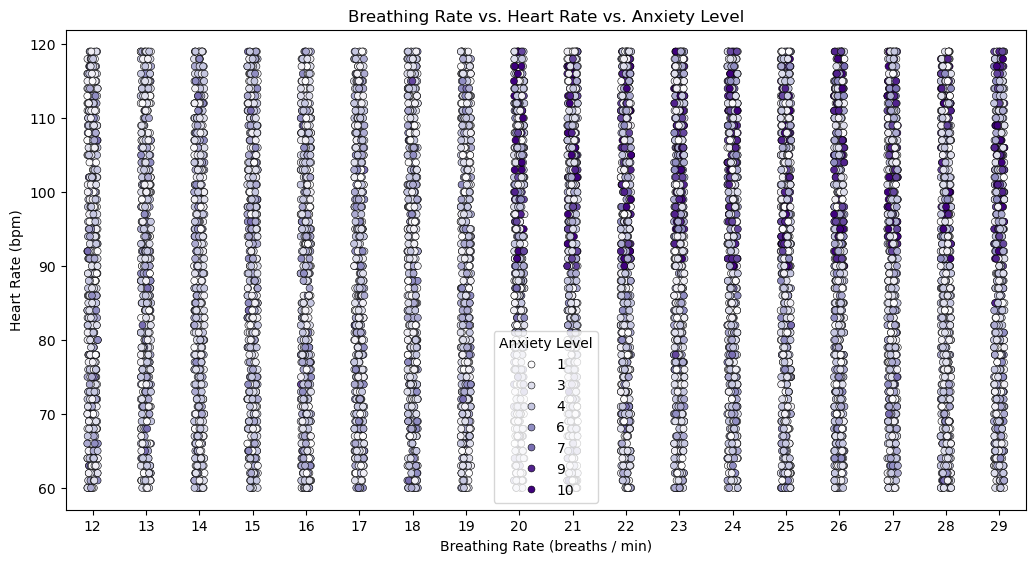

In [127]:
df = raw_df[['Anxiety_level', 'Breathing_rate', 'Heart_rate']]

ax = plt.axes((0,0,1.5,1))
ax = sns.stripplot(data=df, x='Breathing_rate', y='Heart_rate', hue='Anxiety_level', 
                   palette='Purples', s=5, edgecolor='k', linewidth=0.4, ax=ax)
ax.set_xlabel('Breathing Rate (breaths / min)')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_title('Breathing Rate vs. Heart Rate vs. Anxiety Level')
ax.legend(loc='best', title='Anxiety Level')
plt.show()

Key points to observe from the plot:
1. People with high Anxiety have both high Heart Rate and high Breathing Rate.

##### Q12. What effects do Recent Major Life Events and Family History of Anxiety have over Stress and Anxiety Levels?

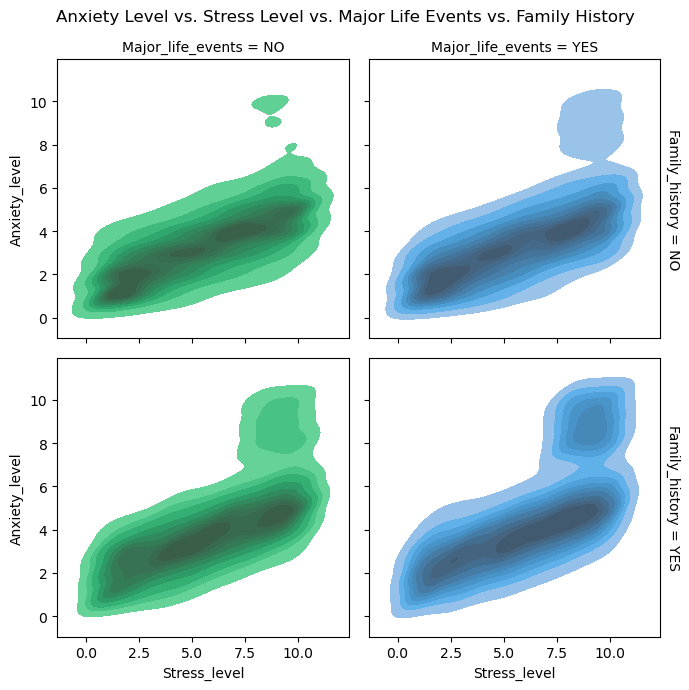

In [128]:
df = raw_df[['Anxiety_level', 'Stress_level', 'Major_life_events', 'Family_history']]

graph = sns.FacetGrid(data=df, col='Major_life_events', row='Family_history', hue='Major_life_events', 
                      palette='viridis', height=3.5, col_order=['NO', 'YES'], despine=False, margin_titles=True)
graph.map(sns.kdeplot, 'Stress_level', 'Anxiety_level', fill=True, levels=10)
plt.suptitle('Anxiety Level vs. Stress Level vs. Major Life Events vs. Family History')
plt.tight_layout()
plt.show()

Key points to observe from the plot:
1. Anxiety Levels are proportional to Stress Levels.
2. There are very less people with high Anxiety and Stress among the ones without both Family History and Major Life Events.
3. Both Family History and Major Life Events increase the chance of a person to have high Anxiety and Stress. Family History has more impact than Major Life Events.
4. There are much more people who have high Axiety and Stress among people with both Family History and Major Life Events.

#### Conclusions

In this EDA Project, I have cleaned and analysed the 'Social Anxiety Dataset' dataset from Kaggle. Here are the key points that can be concluded:
1. Doctor, Athlete, and Nurse are more stressful jobs, whereas Scientist, Chef, and Artist are less stressful jobs, in general.
2. People with higher stress and anxiety levels have higher heart rates. Major life events can have varying effects on people. They can either numb or amplify their heart rates and stress.
3. High caffeine intake can reduce sleep and cause inconsistent sleep timings.
4. Caffeine intake increases with anxiety level. People with high anxiety levels consume considerably high amounts of caffeine.
5. The number of therapy sessions per month is very high among people with high anxiety.
6. People who are conscious about getting enough exercise are also conscious about getting 6-8 hrs of sleep per day consistently. Whereas, people who exercise less are more prone to have inconsistent sleep timings.
7. People with low sleep and low physical activity are also the ones with high stress and anxiety.
8. Anxiety and stress are proportional to each other.
9. Both family history of anxiety and recent major life events increase the chance of a person to have high anxiety and stress.

#### Suggestions

Here are the suggestions that could be taken away from this EDA Project:
1. It is a good habit to have atleast 3-6 hrs of physical activity per week and 6-8 hrs of sleep per day as it will reduce stress and anxiety.
2. People should consume less than 300 mg of caffeine per day so that they can have enough sleep with consistent timings.
3. People who are aware of others who have had anxiety in their family or who have faced any recent major life events can check up on them to make sure they don't develop high stress and anxiety.